# 🚨 Insurance Fraud Detection Model
**Approche :** Détection non-supervisée (pas de labels fraude) + scoring supervisé

**Pipeline :**
1. Feature engineering sur `DWH_FACT_SINISTRE` + `DWH_FACT_EMISSION`
2. Isolation Forest — détection d'anomalies globales
3. Autoencoder — reconstruction error comme score de fraude
4. LOF (Local Outlier Factor) — anomalies locales
5. Ensemble scoring + ranking
6. Explainabilité SHAP
7. Dashboard des sinistres suspects

---
> ⚠️ **Note :** Comme aucun label `FRAUDE` n'existe dans les données, on utilise des méthodes **non-supervisées** pour scorer chaque sinistre. Les dossiers avec les scores les plus élevés sont soumis à un expert pour validation manuelle — ce sont eux qui créent les premiers labels réels.

## 0. Setup

In [63]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# ML
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              classification_report, confusion_matrix,
                              precision_recall_curve, roc_curve)
from sklearn.decomposition import PCA

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Explainability
import shap

import xgboost as xgb
import lightgbm as lgb

plt.rcParams['figure.figsize'] = (13, 5)
sns.set_style('whitegrid')
np.random.seed(42)
tf.random.set_seed(42)

print('✅ Libraries loaded')

✅ Libraries loaded


## 1. Chargement & Jointures

In [64]:
def load_csv(name, date_cols=None, prefix='DWH_FACT_'):
    # Use absolute path to data directory
    base_dir = r'C:\Users\LENOVO\Desktop\PFE_\maghrebia\data\raw'
    path = f'{base_dir}\\{prefix}{name}.csv'
    df = pd.read_csv(path, sep=None, engine='python')
    df.columns = df.columns.str.strip().str.lstrip('\ufeff')
    if date_cols:
        for c in date_cols:
            if c in df.columns:
                df[c] = pd.to_datetime(df[c], errors='coerce')
    return df

sinistre  = load_csv('SINISTRE',   ['DATE_SURVENANCE', 'DATE_DECLARATION'])
emission  = load_csv('EMISSION',   ['DATE_EMISSION', 'DATE_EFFET', 'DATE_ECHEANCE'])
annulation= load_csv('ANNULATION', ['DATE_ANNULATION'])
impaye    = load_csv('IMPAYE',     ['DATE_EMISSION'])

print(f'Sinistres : {len(sinistre):,} lignes')
print(f'Emissions : {len(emission):,} lignes')
sinistre.head(3)

Sinistres : 8,000 lignes
Emissions : 65,000 lignes


,NUM_SINISTRE,ID_BRANCHE,BRANCHE,ID_POLICE,ID_AGENT,ID_CLIENT,ID_VEHICULE,DATE_SURVENANCE,DATE_DECLARATION,ANNEE_SURVENANCE,MOIS_SURVENANCE,NATURE_SINISTRE,RESPONSABILITE,MT_EVALUATION,MT_PAYE,ETAT_SINISTRE
0,SIN000001,3,SANTE,28238,9,24793,NaN,2023-06-26,2023-06-26,2023,6,Pharmacie,0,44.646,32.325,Clos
1,SIN000002,1,AUTO,14359,16,19794,14359.0,2020-09-01,2020-09-01,2020,9,Matériel,50,260.236,0.000,Ouvert
2,SIN000003,1,AUTO,13600,68,27149,13600.0,2022-12-19,2023-01-02,2022,12,Matériel,0,387.062,349.488,Clos


## 2. Feature Engineering — Signaux de Fraude

| Catégorie | Features | Signal fraude |
|---|---|---|
| **Sinistre** | Montant, délai déclaration, ratio payé/évalué | Montant anormalement élevé, déclaration tardive |
| **Historique client** | Nb sinistres passés, fréquence | Client multi-sinistres |
| **Historique agent** | Nb sinistres gérés, avg montant | Agent concentrant des dossiers suspects |
| **Comportement police** | Sinistres proches de l'échéance/souscription | Fraude opportuniste |
| **Réseau** | Clients/véhicules partagés | Réseaux organisés |

In [65]:
df = sinistre.copy()

# ── Feature 1 : Délai déclaration ──────────────────────────────────────────
df['DELAI_DECLARATION'] = (df['DATE_DECLARATION'] - df['DATE_SURVENANCE']).dt.days.clip(0, 365)

# ── Feature 2 : Ratio payé / évalué ────────────────────────────────────────
df['RATIO_PAYE_EVAL'] = np.where(
    df['MT_EVALUATION'] > 0,
    df['MT_PAYE'] / df['MT_EVALUATION'],
    0
)

# ── Feature 3 : Montant relatif (z-score par nature sinistre) ──────────────
df['MT_EVAL_ZSCORE'] = df.groupby('NATURE_SINISTRE')['MT_EVALUATION'].transform(
    lambda x: (x - x.mean()) / (x.std() + 1e-6)
)

# ── Feature 4 : Historique client ──────────────────────────────────────────
client_stats = df.groupby('ID_CLIENT').agg(
    CLIENT_NB_SINISTRES=('NUM_SINISTRE', 'count'),
    CLIENT_MOY_MONTANT=('MT_EVALUATION', 'mean'),
    CLIENT_MAX_MONTANT=('MT_EVALUATION', 'max'),
    CLIENT_STD_MONTANT=('MT_EVALUATION', 'std'),
    CLIENT_RATIO_MATIERES=('NATURE_SINISTRE', lambda x: (x == 'Matériel').mean()),
).reset_index()
client_stats['CLIENT_STD_MONTANT'] = client_stats['CLIENT_STD_MONTANT'].fillna(0)
df = df.merge(client_stats, on='ID_CLIENT', how='left')

# ── Feature 5 : Historique agent ───────────────────────────────────────────
agent_stats = df.groupby('ID_AGENT').agg(
    AGENT_NB_SINISTRES=('NUM_SINISTRE', 'count'),
    AGENT_MOY_MONTANT=('MT_EVALUATION', 'mean'),
    AGENT_TAUX_REFUSE=('ETAT_SINISTRE', lambda x: (x == 'Refusé').mean()),
    AGENT_TAUX_OUVERT=('ETAT_SINISTRE', lambda x: (x == 'Ouvert').mean()),
).reset_index()
df = df.merge(agent_stats, on='ID_AGENT', how='left')

# ── Feature 6 : Historique police (depuis emission) ────────────────────────
police_emission = emission.groupby('ID_POLICE').agg(
    POLICE_DATE_EFFET_MIN=('DATE_EFFET', 'min'),
    POLICE_DATE_ECHEANCE_MAX=('DATE_ECHEANCE', 'max'),
    POLICE_NB_QUITTANCES=('NUM_QUITTANCE', 'count'),
    POLICE_MT_PNET_MOY=('MT_PNET', 'mean'),
    POLICE_BONUS_MALUS_MOY=('BONUS_MALUS', 'mean'),
).reset_index()
df = df.merge(police_emission, on='ID_POLICE', how='left')

# Délai entre souscription et sinistre
df['JOURS_DEPUIS_EFFET'] = (df['DATE_SURVENANCE'] - df['POLICE_DATE_EFFET_MIN']).dt.days.clip(0)
df['JOURS_AVANT_ECHEANCE'] = (df['POLICE_DATE_ECHEANCE_MAX'] - df['DATE_SURVENANCE']).dt.days.clip(0)

# Flag sinistre très tôt après souscription
df['FLAG_SINISTRE_PRECOCE'] = (df['JOURS_DEPUIS_EFFET'] < 30).astype(int)
# Flag sinistre juste avant échéance
df['FLAG_SINISTRE_FIN_CONTRAT'] = (df['JOURS_AVANT_ECHEANCE'] < 30).astype(int)

# ── Feature 7 : Impayés associés à la police ───────────────────────────────
police_impaye = impaye.groupby('ID_POLICE').agg(
    POLICE_NB_IMPAYES=('NUM_QUITTANCE', 'count'),
    POLICE_MT_IMPAYE=('MT_PTT', 'sum'),
).reset_index()
df = df.merge(police_impaye, on='ID_POLICE', how='left')
df[['POLICE_NB_IMPAYES','POLICE_MT_IMPAYE']] = df[['POLICE_NB_IMPAYES','POLICE_MT_IMPAYE']].fillna(0)

# ── Feature 8 : Annulations associées à la police ─────────────────────────
police_ann = annulation.groupby('ID_POLICE').agg(
    POLICE_NB_ANNULATIONS=('NUM_QUITTANCE', 'count'),
).reset_index()
df = df.merge(police_ann, on='ID_POLICE', how='left')
df['POLICE_NB_ANNULATIONS'] = df['POLICE_NB_ANNULATIONS'].fillna(0)

# ── Feature 9 : Véhicule multi-sinistres ───────────────────────────────────
vehicule_stats = df.groupby('ID_VEHICULE').agg(
    VEHICULE_NB_SINISTRES=('NUM_SINISTRE', 'count'),
    VEHICULE_MOY_MONTANT=('MT_EVALUATION', 'mean'),
).reset_index()
df = df.merge(vehicule_stats, on='ID_VEHICULE', how='left')

# ── Feature 10 : Mois de survenance (saisonnalité) ─────────────────────────
df['MOIS_SURVENANCE'] = df['DATE_SURVENANCE'].dt.month
df['JOUR_SEMAINE'] = df['DATE_SURVENANCE'].dt.dayofweek  # 0=lundi, 6=dimanche
df['FLAG_WEEKEND'] = (df['JOUR_SEMAINE'] >= 5).astype(int)

# ── Encodage catégoriel ────────────────────────────────────────────────────
le_nature = LabelEncoder()
df['NATURE_SINISTRE_ENC'] = le_nature.fit_transform(df['NATURE_SINISTRE'].fillna('Inconnu'))

le_etat = LabelEncoder()
df['ETAT_SINISTRE_ENC'] = le_etat.fit_transform(df['ETAT_SINISTRE'].fillna('Inconnu'))

print(f'Dataset enrichi : {df.shape}')
df[['NUM_SINISTRE','MT_EVALUATION','DELAI_DECLARATION','MT_EVAL_ZSCORE',
    'CLIENT_NB_SINISTRES','FLAG_SINISTRE_PRECOCE','POLICE_NB_IMPAYES']].head()

Dataset enrichi : (8000, 46)


,NUM_SINISTRE,MT_EVALUATION,DELAI_DECLARATION,MT_EVAL_ZSCORE,CLIENT_NB_SINISTRES,FLAG_SINISTRE_PRECOCE,POLICE_NB_IMPAYES
0,SIN000001,44.646,0.0,-1.077070,3,0,0.0
1,SIN000002,260.236,0.0,-0.649696,1,1,0.0
2,SIN000003,387.062,14.0,-0.596590,1,0,0.0
3,SIN000004,4076.666,1.0,-0.229700,1,0,0.0
4,SIN000005,3528.517,15.0,-0.263222,2,0,1.0


In [66]:
# ── Sélection finale des features ─────────────────────────────────────────
FEATURE_COLS = [
    # Sinistre
    'MT_EVALUATION', 'MT_PAYE', 'RATIO_PAYE_EVAL', 'MT_EVAL_ZSCORE',
    'DELAI_DECLARATION', 'RESPONSABILITE', 'NATURE_SINISTRE_ENC', 'ETAT_SINISTRE_ENC',
    # Client
    'CLIENT_NB_SINISTRES', 'CLIENT_MOY_MONTANT', 'CLIENT_MAX_MONTANT',
    'CLIENT_STD_MONTANT', 'CLIENT_RATIO_MATIERES',
    # Agent
    'AGENT_NB_SINISTRES', 'AGENT_MOY_MONTANT', 'AGENT_TAUX_REFUSE', 'AGENT_TAUX_OUVERT',
    # Police
    'POLICE_NB_QUITTANCES', 'POLICE_MT_PNET_MOY', 'POLICE_BONUS_MALUS_MOY',
    'JOURS_DEPUIS_EFFET', 'JOURS_AVANT_ECHEANCE',
    'FLAG_SINISTRE_PRECOCE', 'FLAG_SINISTRE_FIN_CONTRAT',
    'POLICE_NB_IMPAYES', 'POLICE_MT_IMPAYE', 'POLICE_NB_ANNULATIONS',
    # Véhicule
    'VEHICULE_NB_SINISTRES', 'VEHICULE_MOY_MONTANT',
    # Temporel
    'MOIS_SURVENANCE', 'JOUR_SEMAINE', 'FLAG_WEEKEND',
]

# Garder seulement les colonnes présentes
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]

X = df[FEATURE_COLS].fillna(0)
print(f'Features sélectionnées : {len(FEATURE_COLS)}')
print(X.describe().T[['mean','std','min','max']])

Features sélectionnées : 32
                                   mean           std           min  \
MT_EVALUATION              2.805492e+03   9271.986699     17.071000   
MT_PAYE                    1.774735e+03   7066.826991      0.000000   
RATIO_PAYE_EVAL            6.338819e-01      0.377081      0.000000   
MT_EVAL_ZSCORE             9.769963e-18      0.999437     -1.539200   
DELAI_DECLARATION          1.267600e+01     17.365425      0.000000   
RESPONSABILITE             4.104375e+01     43.333968      0.000000   
NATURE_SINISTRE_ENC        5.283875e+00      2.904151      0.000000   
ETAT_SINISTRE_ENC          3.203750e-01      0.592477      0.000000   
CLIENT_NB_SINISTRES        1.622750e+00      0.893886      1.000000   
CLIENT_MOY_MONTANT         2.805492e+03   8397.112333     17.071000   
CLIENT_MAX_MONTANT         3.753759e+03  11186.006330     17.071000   
CLIENT_STD_MONTANT         1.041775e+03   5056.037731      0.000000   
CLIENT_RATIO_MATIERES      3.793750e-01      0.44

## 3. Analyse Exploratoire des Signaux Fraude

In [67]:
fig = make_subplots(rows=2, cols=3,
    subplot_titles=[
        'Distribution MT_EVALUATION', 'Délai Déclaration (jours)',
        'Nb Sinistres / Client', 'Ratio Payé/Évalué',
        'Sinistres par Nature', 'Jours depuis Effet'
    ])

# MT_EVALUATION
fig.add_trace(go.Histogram(x=df['MT_EVALUATION'].clip(0, 20000), nbinsx=60,
                            name='MT Evaluation', marker_color='steelblue'), row=1, col=1)

# Délai déclaration
fig.add_trace(go.Histogram(x=df['DELAI_DECLARATION'].clip(0, 90), nbinsx=40,
                            name='Délai', marker_color='orange'), row=1, col=2)

# Nb sinistres / client
client_nb = df.groupby('ID_CLIENT').size().value_counts().sort_index()
fig.add_trace(go.Bar(x=client_nb.index.astype(str), y=client_nb.values,
                     name='Sinistres/Client', marker_color='green'), row=1, col=3)

# Ratio payé/évalué
fig.add_trace(go.Histogram(x=df['RATIO_PAYE_EVAL'].clip(0, 1), nbinsx=50,
                            name='Ratio', marker_color='crimson'), row=2, col=1)

# Nature sinistre
nature_cnt = df['NATURE_SINISTRE'].value_counts().head(8)
fig.add_trace(go.Bar(x=nature_cnt.values, y=nature_cnt.index, orientation='h',
                     marker_color='purple'), row=2, col=2)

# Jours depuis effet
fig.add_trace(go.Histogram(x=df['JOURS_DEPUIS_EFFET'].clip(0, 1000), nbinsx=50,
                            name='Jours effet', marker_color='teal'), row=2, col=3)

fig.update_layout(height=600, title_text='📊 Analyse des Signaux de Fraude',
                  showlegend=False)
fig.show()

<Figure size 1300x500 with 0 Axes>

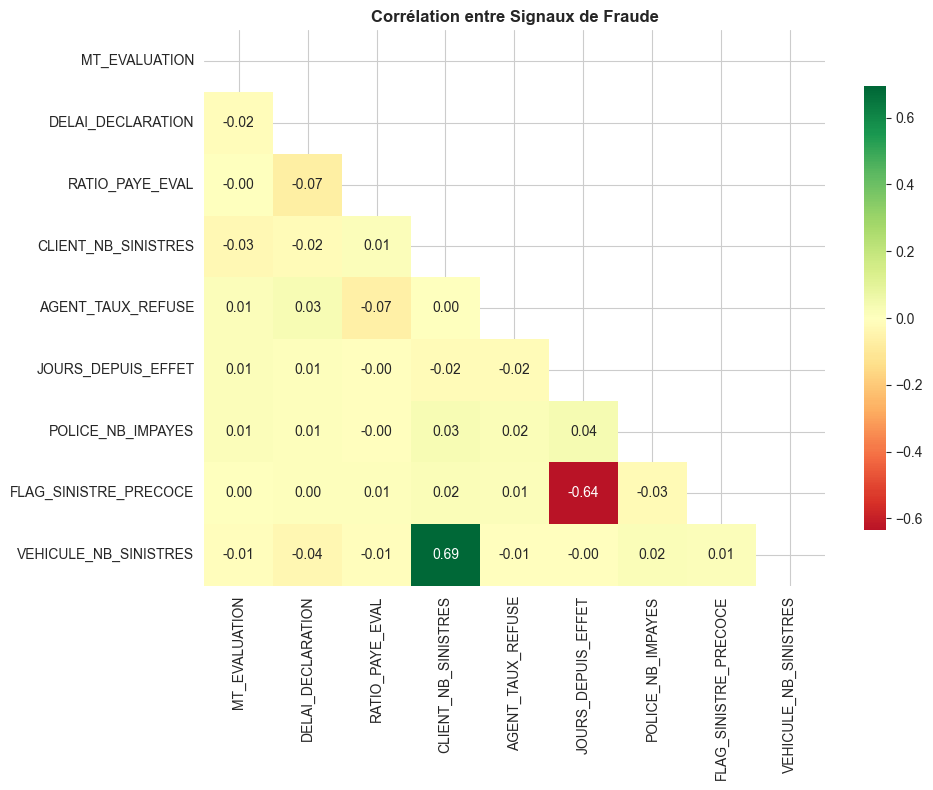

In [68]:
# Matrice de corrélation des features clés
corr_cols = ['MT_EVALUATION', 'DELAI_DECLARATION', 'RATIO_PAYE_EVAL',
             'CLIENT_NB_SINISTRES', 'AGENT_TAUX_REFUSE', 'JOURS_DEPUIS_EFFET',
             'POLICE_NB_IMPAYES', 'FLAG_SINISTRE_PRECOCE', 'VEHICULE_NB_SINISTRES']
corr_cols = [c for c in corr_cols if c in df.columns]

fig, ax = plt.subplots(figsize=(10, 8))
corr_mat = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, cbar_kws={'shrink': .8})
ax.set_title('Corrélation entre Signaux de Fraude', fontweight='bold')
plt.tight_layout(); plt.show()

## 4. Modèle 1 — Isolation Forest
> Principe : isole les points anormaux en créant des partitions aléatoires. Les anomalies sont isolées en peu de coupures → score d'anomalie élevé.

Isolation Forest — suspects détectés : 400 (5.0%)
Score moyen suspects   : 0.545
Score moyen normaux    : 0.198


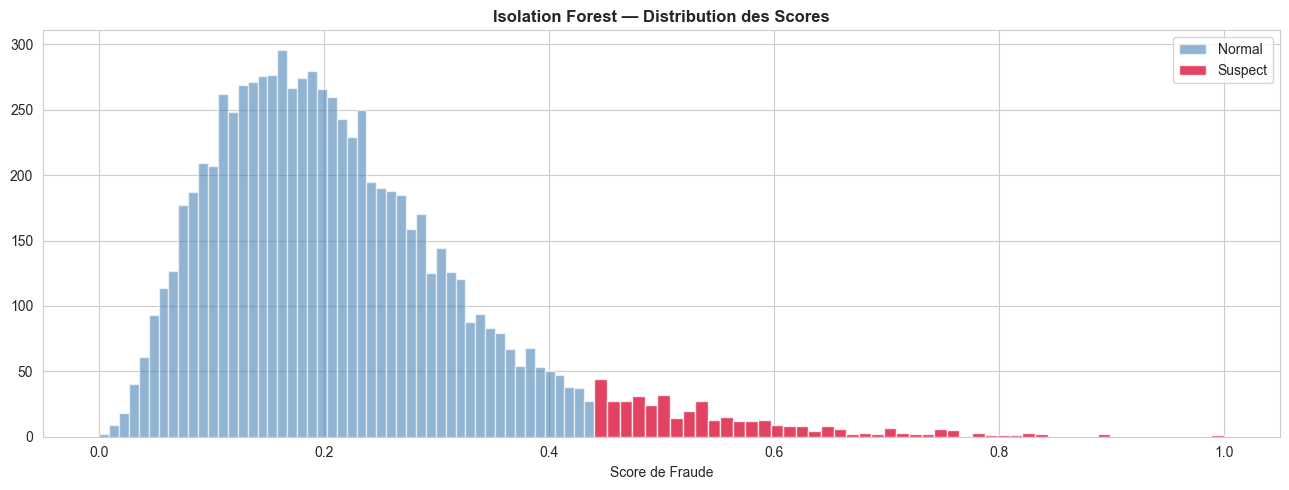

In [69]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

iso_forest = IsolationForest(
    n_estimators=300,
    contamination=0.05,   # on suppose ~5% de dossiers suspects
    max_features=0.8,
    random_state=42,
    n_jobs=-1
)
iso_forest.fit(X_scaled)

# Score : plus c'est négatif → plus c'est anormal
# On le transforme en score de fraude [0, 1]
raw_scores = iso_forest.decision_function(X_scaled)
df['SCORE_ISOLATION_FOREST'] = 1 - (raw_scores - raw_scores.min()) / (raw_scores.max() - raw_scores.min())
df['FLAG_IF'] = (iso_forest.predict(X_scaled) == -1).astype(int)

print(f'Isolation Forest — suspects détectés : {df["FLAG_IF"].sum()} ({df["FLAG_IF"].mean()*100:.1f}%)')
print(f'Score moyen suspects   : {df[df["FLAG_IF"]==1]["SCORE_ISOLATION_FOREST"].mean():.3f}')
print(f'Score moyen normaux    : {df[df["FLAG_IF"]==0]["SCORE_ISOLATION_FOREST"].mean():.3f}')

# Distribution des scores
fig, ax = plt.subplots()
ax.hist(df.loc[df['FLAG_IF']==0, 'SCORE_ISOLATION_FOREST'], bins=50, alpha=0.6,
        label='Normal', color='steelblue')
ax.hist(df.loc[df['FLAG_IF']==1, 'SCORE_ISOLATION_FOREST'], bins=50, alpha=0.8,
        label='Suspect', color='crimson')
ax.set_title('Isolation Forest — Distribution des Scores', fontweight='bold')
ax.set_xlabel('Score de Fraude'); ax.legend()
plt.tight_layout(); plt.show()

## 5. Modèle 2 — Autoencoder
> Principe : le réseau apprend à reconstruire les sinistres normaux. Les fraudes ont une erreur de reconstruction élevée car elles ne ressemblent pas aux patterns normaux.

Model: "autoencoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input (InputLayer)          [(None, 32)]              0         
                                                                 
 dense_16 (Dense)            (None, 32)                1056      
                                                                 
 dropout_4 (Dropout)         (None, 32)                0         
                                                                 
 dense_17 (Dense)            (None, 16)                528       
                                                                 
 bottleneck (Dense)          (None, 8)                 136       
                                                                 
 dense_18 (Dense)            (None, 16)                144       
                                                                 
 dense_19 (Dense)            (None, 32)                

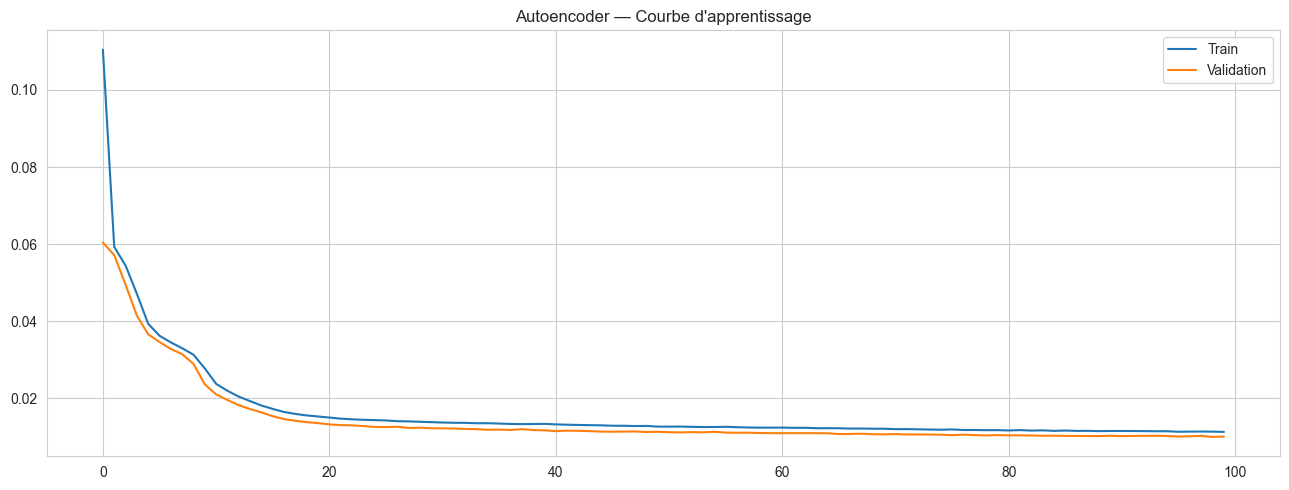

In [70]:
# Normalisation [0, 1] pour l'autoencoder
scaler_ae = MinMaxScaler()
X_ae = scaler_ae.fit_transform(X)
input_dim = X_ae.shape[1]

# Architecture : Encoder → Bottleneck → Decoder
def build_autoencoder(input_dim, encoding_dim=8):
    inp = Input(shape=(input_dim,), name='input')

    # Encoder
    x = Dense(32, activation='relu')(inp)
    x = Dropout(0.1)(x)
    x = Dense(16, activation='relu')(x)
    encoded = Dense(encoding_dim, activation='relu', name='bottleneck')(x)

    # Decoder
    x = Dense(16, activation='relu')(encoded)
    x = Dense(32, activation='relu')(x)
    decoded = Dense(input_dim, activation='sigmoid', name='output')(x)

    autoencoder = Model(inp, decoded, name='autoencoder')
    encoder_model = Model(inp, encoded, name='encoder')
    autoencoder.compile(optimizer='adam', loss='mse')
    return autoencoder, encoder_model

autoencoder, encoder = build_autoencoder(input_dim, encoding_dim=8)
autoencoder.summary()

es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = autoencoder.fit(
    X_ae, X_ae,
    epochs=100, batch_size=64,
    validation_split=0.15,
    callbacks=[es], verbose=0
)

print(f'Training terminé en {len(history.history["loss"])} epochs')

# Courbe de loss
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Autoencoder — Courbe d\'apprentissage'); plt.legend()
plt.tight_layout(); plt.show()

Autoencoder — suspects détectés : 400 (5.0%)


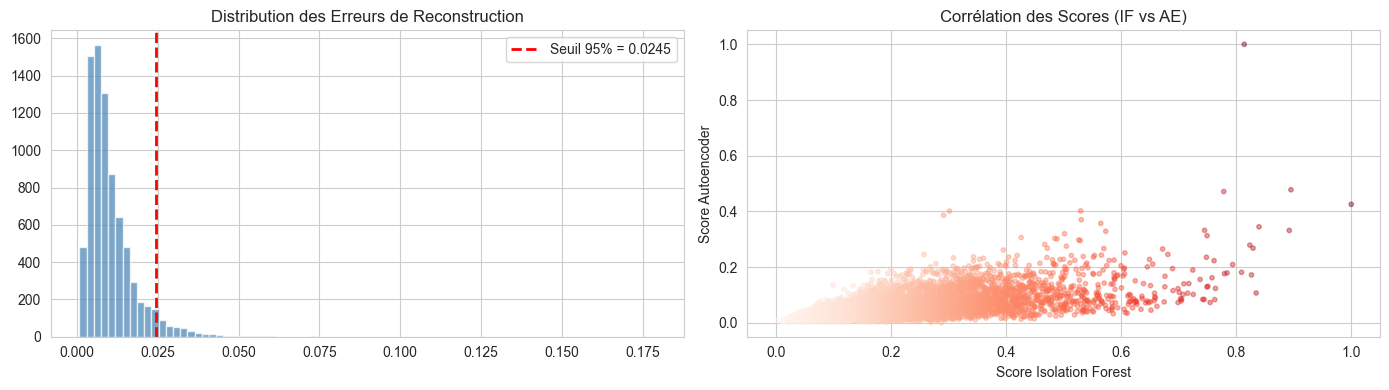

In [71]:
# Erreur de reconstruction = score de fraude
X_reconstructed = autoencoder.predict(X_ae, verbose=0)
reconstruction_errors = np.mean(np.power(X_ae - X_reconstructed, 2), axis=1)

# Normalisation [0, 1]
df['SCORE_AUTOENCODER'] = (reconstruction_errors - reconstruction_errors.min()) / \
                           (reconstruction_errors.max() - reconstruction_errors.min())

# Seuil = percentile 95
threshold_ae = np.percentile(reconstruction_errors, 95)
df['FLAG_AE'] = (reconstruction_errors > threshold_ae).astype(int)

print(f'Autoencoder — suspects détectés : {df["FLAG_AE"].sum()} ({df["FLAG_AE"].mean()*100:.1f}%)')

# Distribution des erreurs
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(reconstruction_errors, bins=80, color='steelblue', alpha=0.7)
axes[0].axvline(threshold_ae, color='red', linestyle='--', linewidth=2, label=f'Seuil 95% = {threshold_ae:.4f}')
axes[0].set_title('Distribution des Erreurs de Reconstruction'); axes[0].legend()

# Scatter : score AE vs score IF
axes[1].scatter(df['SCORE_ISOLATION_FOREST'], df['SCORE_AUTOENCODER'],
                c=np.maximum(df['SCORE_ISOLATION_FOREST'], df['SCORE_AUTOENCODER']),
                cmap='Reds', alpha=0.4, s=10)
axes[1].set_xlabel('Score Isolation Forest'); axes[1].set_ylabel('Score Autoencoder')
axes[1].set_title('Corrélation des Scores (IF vs AE)')
plt.tight_layout(); plt.show()

## 6. Modèle 3 — Local Outlier Factor (LOF)
> Principe : compare la densité locale de chaque point avec ses voisins. Un sinistre dans une zone peu dense = anomalie.

In [72]:
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.05,
    novelty=False,
    n_jobs=-1
)
lof_labels = lof.fit_predict(X_scaled)
lof_scores = -lof.negative_outlier_factor_   # Plus élevé = plus anormal

df['SCORE_LOF'] = (lof_scores - lof_scores.min()) / (lof_scores.max() - lof_scores.min())
df['FLAG_LOF'] = (lof_labels == -1).astype(int)

print(f'LOF — suspects détectés : {df["FLAG_LOF"].sum()} ({df["FLAG_LOF"].mean()*100:.1f}%)')

LOF — suspects détectés : 400 (5.0%)


## 7. Score Ensemble — Combinaison des 3 Modèles

In [73]:
# Poids : IF=40%, AE=40%, LOF=20%
df['FRAUD_SCORE'] = (
    0.40 * df['SCORE_ISOLATION_FOREST'] +
    0.40 * df['SCORE_AUTOENCODER'] +
    0.20 * df['SCORE_LOF']
)

# Seuils de risque
p90 = df['FRAUD_SCORE'].quantile(0.90)
p95 = df['FRAUD_SCORE'].quantile(0.95)
p99 = df['FRAUD_SCORE'].quantile(0.99)

df['RISK_LEVEL'] = pd.cut(
    df['FRAUD_SCORE'],
    bins=[-np.inf, p90, p95, p99, np.inf],
    labels=['Normal', 'Risque Modéré', 'Risque Élevé', 'Critique']
)

print('\n=== Répartition des niveaux de risque ===')
risk_counts = df['RISK_LEVEL'].value_counts()
print(risk_counts)

print(f'\nSeuils : p90={p90:.3f} | p95={p95:.3f} | p99={p99:.3f}')

# Donut chart
colors = ['#2ecc71', '#f39c12', '#e67e22', '#c0392b']
fig = go.Figure(go.Pie(
    labels=risk_counts.index,
    values=risk_counts.values,
    hole=0.5,
    marker_colors=colors
))
fig.update_layout(title='Répartition des Niveaux de Risque (Ensemble)',
                  height=400)
fig.show()


=== Répartition des niveaux de risque ===
RISK_LEVEL
Normal           7200
Risque Modéré     400
Risque Élevé      320
Critique           80
Name: count, dtype: int64

Seuils : p90=0.188 | p95=0.225 | p99=0.314


In [74]:
# Vue d'ensemble : Fraud Score par Nature de Sinistre
fig = px.box(
    df, x='NATURE_SINISTRE', y='FRAUD_SCORE',
    color='NATURE_SINISTRE',
    title='Score de Fraude par Nature de Sinistre',
    labels={'FRAUD_SCORE': 'Score de Fraude', 'NATURE_SINISTRE': 'Nature'},
)
fig.update_layout(showlegend=False, height=450)
fig.show()

# Score vs Montant
fig2 = px.scatter(
    df, x='MT_EVALUATION', y='FRAUD_SCORE',
    color='RISK_LEVEL',
    color_discrete_map={
        'Normal': '#2ecc71', 'Risque Modéré': '#f39c12',
        'Risque Élevé': '#e67e22', 'Critique': '#c0392b'
    },
    opacity=0.5,
    title='Fraud Score vs Montant Évaluation',
    labels={'MT_EVALUATION': 'MT Évaluation (TND)', 'FRAUD_SCORE': 'Score de Fraude'},
    log_x=True
)
fig2.update_layout(height=450)
fig2.show()

## 8. Explainabilité avec SHAP
On entraîne un Random Forest sur les suspects vs normaux (via le score ensemble) pour expliquer **pourquoi** un sinistre est suspect.

Positifs (suspects) : 400
Négatifs (normaux)  : 7600
RF OOB accuracy: n/a (oob_score pas activé en mode speed)


<Figure size 1000x700 with 0 Axes>

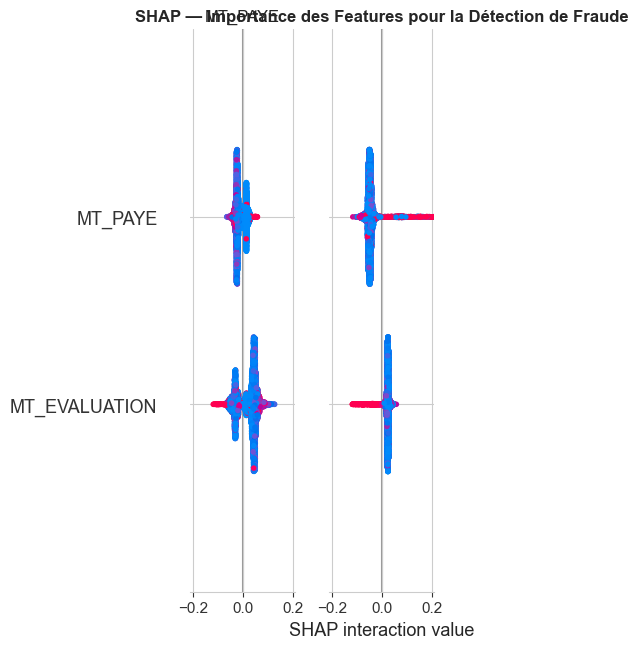

In [75]:
# Label pseudo-fraude : top 5% de fraud_score = suspecté
df['PSEUDO_FRAUDE'] = (df['FRAUD_SCORE'] >= df['FRAUD_SCORE'].quantile(0.95)).astype(int)

print(f'Positifs (suspects) : {df["PSEUDO_FRAUDE"].sum()}')
print(f'Négatifs (normaux)  : {(df["PSEUDO_FRAUDE"]==0).sum()}')

# Random Forest pour SHAP
rf = RandomForestClassifier(
    n_estimators=200, max_depth=6, class_weight='balanced',
    random_state=42, n_jobs=-1
)
rf.fit(X, df['PSEUDO_FRAUDE'])
print(f'RF OOB accuracy: n/a (oob_score pas activé en mode speed)')

# SHAP values
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X)

# Summary plot
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values[1] if isinstance(shap_values, list) else shap_values,
    X,
    feature_names=FEATURE_COLS,
    plot_type='bar',
    show=False
)
plt.title('SHAP — Importance des Features pour la Détection de Fraude', fontweight='bold')
plt.tight_layout(); plt.show()

<Figure size 1000x800 with 0 Axes>

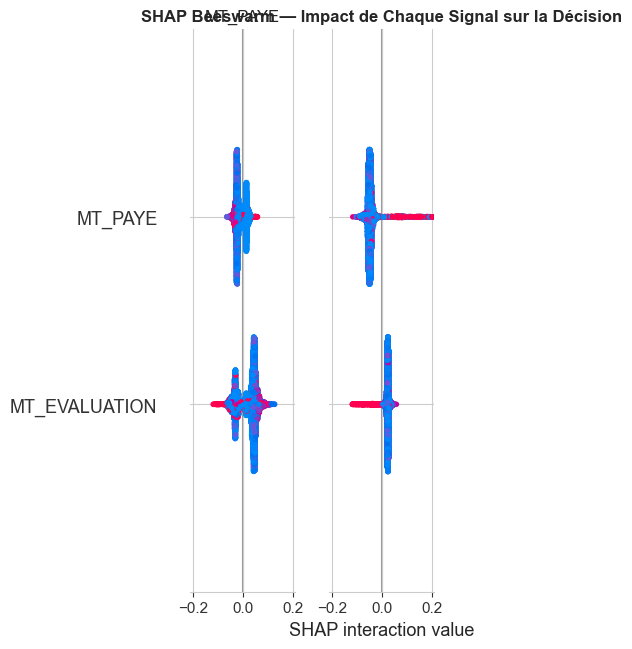

In [76]:
# Beeswarm SHAP — impact positif/négatif de chaque feature
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values[1] if isinstance(shap_values, list) else shap_values,
    X,
    feature_names=FEATURE_COLS,
    show=False
)
plt.title('SHAP Beeswarm — Impact de Chaque Signal sur la Décision', fontweight='bold')
plt.tight_layout(); plt.show()

=== DOSSIER LE PLUS SUSPECT ===
NUM_SINISTRE     : SIN006104
NATURE           : Incendie
MT_EVALUATION    : 358,812 TND
DELAI_DECLARATION: 6 jours
CLIENT_NB_SIN    : 1
FRAUD_SCORE      : 0.7989
RISK_LEVEL       : Critique


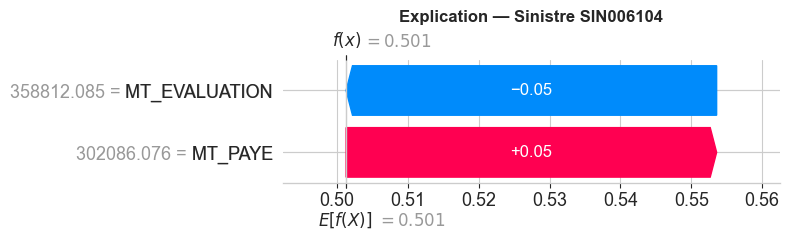

In [77]:
# Explication d'un cas individuel suspect
top_suspect_idx = df['FRAUD_SCORE'].idxmax()
suspect = df.loc[top_suspect_idx]

print('=== DOSSIER LE PLUS SUSPECT ===')
print(f"NUM_SINISTRE     : {suspect['NUM_SINISTRE']}")
print(f"NATURE           : {suspect['NATURE_SINISTRE']}")
print(f"MT_EVALUATION    : {suspect['MT_EVALUATION']:,.0f} TND")
print(f"DELAI_DECLARATION: {suspect['DELAI_DECLARATION']:.0f} jours")
print(f"CLIENT_NB_SIN    : {suspect['CLIENT_NB_SINISTRES']:.0f}")
print(f"FRAUD_SCORE      : {suspect['FRAUD_SCORE']:.4f}")
print(f"RISK_LEVEL       : {suspect['RISK_LEVEL']}")

# SHAP waterfall pour ce cas
shap_vals = shap_values[1] if isinstance(shap_values, list) else shap_values
plt.figure()
# Always select a single 1D explanation vector for waterfall plot
if shap_vals.ndim == 3:
    # Multi-output, multi-class: select the right output/class (usually 1 for binary classification)
    single_explanation = shap_vals[top_suspect_idx, 1, :]
    base_value = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value
elif shap_vals.ndim == 2:
    # Multi-output or single-output
    if shap_vals.shape[1] == len(FEATURE_COLS):
        single_explanation = shap_vals[top_suspect_idx]
        base_value = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) and len(explainer.expected_value) > 1 else explainer.expected_value
    else:
        # shape (n_samples, n_outputs), pick output 1 for binary classification
        single_explanation = shap_vals[top_suspect_idx, 1]
        base_value = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value
else:
    single_explanation = shap_vals[top_suspect_idx]
    base_value = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) and len(explainer.expected_value) > 1 else explainer.expected_value

shap.waterfall_plot(
    shap.Explanation(
        values=single_explanation,
        base_values=base_value,
        data=X.iloc[top_suspect_idx].values,
        feature_names=FEATURE_COLS
    ),
    show=False
)
plt.title(f'Explication — Sinistre {suspect["NUM_SINISTRE"]}', fontweight='bold')
plt.tight_layout(); plt.show()

## 9. Analyse Réseau — Clients & Agents suspects

In [78]:
# Aggrégation par agent
agent_fraud = df.groupby('ID_AGENT').agg(
    NB_SINISTRES=('NUM_SINISTRE', 'count'),
    FRAUD_SCORE_MOY=('FRAUD_SCORE', 'mean'),
    FRAUD_SCORE_MAX=('FRAUD_SCORE', 'max'),
    NB_CRITIQUES=('RISK_LEVEL', lambda x: (x == 'Critique').sum()),
    MT_TOTAL=('MT_EVALUATION', 'sum'),
).sort_values('FRAUD_SCORE_MOY', ascending=False)

print('=== TOP 10 AGENTS AVEC SCORE FRAUDE MOYEN LE PLUS ÉLEVÉ ===')
display(agent_fraud.head(10))

# Scatter agents
fig = px.scatter(
    agent_fraud.reset_index(),
    x='NB_SINISTRES', y='FRAUD_SCORE_MOY',
    size='MT_TOTAL', color='FRAUD_SCORE_MOY',
    color_continuous_scale='Reds',
    hover_data=['ID_AGENT', 'NB_CRITIQUES', 'MT_TOTAL'],
    title='Profil Fraude par Agent (taille = MT total géré)',
    labels={'NB_SINISTRES': 'Nb Sinistres', 'FRAUD_SCORE_MOY': 'Score Fraude Moyen'}
)
fig.update_layout(height=450)
fig.show()

=== TOP 10 AGENTS AVEC SCORE FRAUDE MOYEN LE PLUS ÉLEVÉ ===


,NB_SINISTRES,FRAUD_SCORE_MOY,FRAUD_SCORE_MAX,NB_CRITIQUES,MT_TOTAL
ID_AGENT,,,,,
66,36,0.239474,0.528810,7,399359.561
163,29,0.235174,0.798893,2,452279.030
15,38,0.182453,0.382184,2,240721.672
16,47,0.182071,0.360853,3,321229.033
135,39,0.179681,0.322933,1,44991.423
60,28,0.155136,0.296868,0,35468.525
116,30,0.154710,0.378852,6,98812.959
131,41,0.152599,0.324632,2,198134.544
89,48,0.151782,0.448460,2,195264.117


In [79]:
# Agrégation par client
client_fraud = df.groupby('ID_CLIENT').agg(
    NB_SINISTRES=('NUM_SINISTRE', 'count'),
    FRAUD_SCORE_MOY=('FRAUD_SCORE', 'mean'),
    MT_TOTAL=('MT_EVALUATION', 'sum'),
    NATURE_PLUS_FREQ=('NATURE_SINISTRE', lambda x: x.mode()[0] if len(x) > 0 else 'N/A'),
).sort_values('FRAUD_SCORE_MOY', ascending=False)

print('=== TOP 15 CLIENTS LES PLUS SUSPECTS ===')
display(client_fraud.head(15))

=== TOP 15 CLIENTS LES PLUS SUSPECTS ===


,NB_SINISTRES,FRAUD_SCORE_MOY,MT_TOTAL,NATURE_PLUS_FREQ
ID_CLIENT,,,,
10219,1,0.798893,358812.085,Incendie
24650,1,0.528810,184512.496,Vol
8323,1,0.505205,200347.050,Incendie
17146,2,0.472043,208183.408,Dégât des eaux
12891,4,0.459439,209367.478,Vol
15012,1,0.459193,38733.450,Matériel
14893,1,0.457188,62935.506,Vol
27378,1,0.456308,120054.384,Vol
25057,1,0.420933,167103.337,Incendie


## 10. PCA — Visualisation 2D des Suspects

In [80]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'RISK_LEVEL': df['RISK_LEVEL'].astype(str),
    'FRAUD_SCORE': df['FRAUD_SCORE'],
    'MT_EVALUATION': df['MT_EVALUATION'],
    'NATURE_SINISTRE': df['NATURE_SINISTRE'],
})

fig = px.scatter(
    pca_df, x='PC1', y='PC2',
    color='RISK_LEVEL',
    color_discrete_map={
        'Normal': '#2ecc71', 'Risque Modéré': '#f39c12',
        'Risque Élevé': '#e67e22', 'Critique': '#c0392b'
    },
    opacity=0.5,
    hover_data=['MT_EVALUATION', 'NATURE_SINISTRE', 'FRAUD_SCORE'],
    title='PCA 2D — Clusters de Sinistres (Normal vs Suspects)',
    labels={'PC1': f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)',
            'PC2': f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)'}
)
fig.update_layout(height=500)
fig.show()

## 11. Liste des Dossiers à Investiguer (Output opérationnel)

In [81]:
# Top dossiers suspects à soumettre aux experts
investigation_cols = [
    'NUM_SINISTRE', 'BRANCHE', 'NATURE_SINISTRE',
    'DATE_SURVENANCE', 'DATE_DECLARATION',
    'MT_EVALUATION', 'MT_PAYE',
    'DELAI_DECLARATION', 'CLIENT_NB_SINISTRES',
    'FLAG_SINISTRE_PRECOCE', 'FLAG_SINISTRE_FIN_CONTRAT',
    'POLICE_NB_IMPAYES', 'ETAT_SINISTRE',
    'SCORE_ISOLATION_FOREST', 'SCORE_AUTOENCODER', 'SCORE_LOF', 'FRAUD_SCORE', 'RISK_LEVEL'
]
investigation_cols = [c for c in investigation_cols if c in df.columns]

suspects_top = (
    df[df['RISK_LEVEL'].isin(['Critique', 'Risque Élevé'])]
    [investigation_cols]
    .sort_values('FRAUD_SCORE', ascending=False)
    .reset_index(drop=True)
)

print(f'Dossiers à investiguer : {len(suspects_top)}')
display(
    suspects_top.head(20).style
    .background_gradient(subset=['FRAUD_SCORE'], cmap='Reds')
    .format({
        'MT_EVALUATION': '{:,.0f}',
        'MT_PAYE': '{:,.0f}',
        'FRAUD_SCORE': '{:.4f}',
        'SCORE_ISOLATION_FOREST': '{:.3f}',
        'SCORE_AUTOENCODER': '{:.3f}',
        'SCORE_LOF': '{:.3f}',
    })
)

Dossiers à investiguer : 400


,NUM_SINISTRE,BRANCHE,NATURE_SINISTRE,DATE_SURVENANCE,DATE_DECLARATION,MT_EVALUATION,MT_PAYE,DELAI_DECLARATION,CLIENT_NB_SINISTRES,FLAG_SINISTRE_PRECOCE,FLAG_SINISTRE_FIN_CONTRAT,POLICE_NB_IMPAYES,ETAT_SINISTRE,SCORE_ISOLATION_FOREST,SCORE_AUTOENCODER,SCORE_LOF,FRAUD_SCORE,RISK_LEVEL
0,SIN006104,IRDS,Incendie,2022-03-12 00:00:00,2022-03-18 00:00:00,"358,812","302,086",6.000000,1,0,0,0.000000,Clos,0.814,1.000,0.366,0.7989,Critique
1,SIN004997,IRDS,Incendie,2020-03-05 00:00:00,2020-03-19 00:00:00,"204,460","153,348",14.000000,4,1,0,1.000000,Clos,1.000,0.425,0.138,0.5977,Critique
2,SIN004895,IRDS,Dégât des eaux,2022-08-08 00:00:00,2022-08-15 00:00:00,"207,794","181,575",7.000000,2,0,0,0.000000,Clos,0.895,0.478,0.153,0.5798,Critique
3,SIN006909,IRDS,Vol,2022-11-18 00:00:00,2022-11-24 00:00:00,"184,512",0,6.000000,1,0,1,0.000000,Ouvert,0.778,0.471,0.144,0.5288,Critique
4,SIN003560,IRDS,Dégât des eaux,2024-11-11 00:00:00,2024-11-15 00:00:00,"159,152","116,201",4.000000,2,0,1,0.000000,Clos,0.892,0.332,0.108,0.5112,Critique
5,SIN002667,IRDS,Incendie,2022-07-30 00:00:00,2022-08-03 00:00:00,"200,347","200,331",4.000000,1,0,0,0.000000,Clos,0.840,0.345,0.157,0.5052,Critique
6,SIN005320,AUTO,Matériel,2024-01-21 00:00:00,2024-02-05 00:00:00,"38,733","31,992",15.000000,1,0,1,0.000000,Clos,0.745,0.332,0.141,0.4592,Critique
7,SIN005528,IRDS,Vol,2020-04-17 00:00:00,2020-04-27 00:00:00,"62,936",0,10.000000,1,0,0,1.000000,Refusé,0.824,0.279,0.081,0.4572,Critique
8,SIN003125,IRDS,Vol,2024-10-12 00:00:00,2025-01-08 00:00:00,"120,054",0,88.000000,1,0,1,0.000000,Refusé,0.829,0.268,0.087,0.4563,Critique
9,SIN004364,AUTO,Matériel,2022-03-01 00:00:00,2022-05-22 00:00:00,"1,198",0,82.000000,4,1,0,0.000000,Ouvert,0.749,0.313,0.118,0.4485,Critique
